Searching for audio files...
Number of audio files found: 3014

Reading protocol files...
Number of protocol files found: 3
Protocol rows: 18030
Labels available in protocol: 18030

Extracting MFCC features...
This may take some time.

================ DATASET =================
X shape: (3014, 26)
y shape: (3014,)
Class distribution: (array([0, 1]), array([1507, 1507]))

A1 - Entropy: 1.0
A2 - Gini Index: 0.5

A4 - Equal-width binning completed.
Number of bins: 4

A3 - ROOT FEATURE
Root feature: MFCC_Mean_9
Feature index: 8
Maximum Information Gain: 0.4515061404508671

Information Gain of all features:
     Feature  Information_Gain
 MFCC_Mean_9          0.451506
 MFCC_Mean_5          0.389905
 MFCC_Mean_7          0.326870
MFCC_Mean_11          0.281877
MFCC_Mean_12          0.262693
 MFCC_Mean_1          0.196768
MFCC_Mean_10          0.098592
 MFCC_Mean_6          0.092405
  MFCC_Std_1          0.090847
  MFCC_Std_2          0.079575
 MFCC_Mean_2          0.063817
 MFCC_Mean_8      

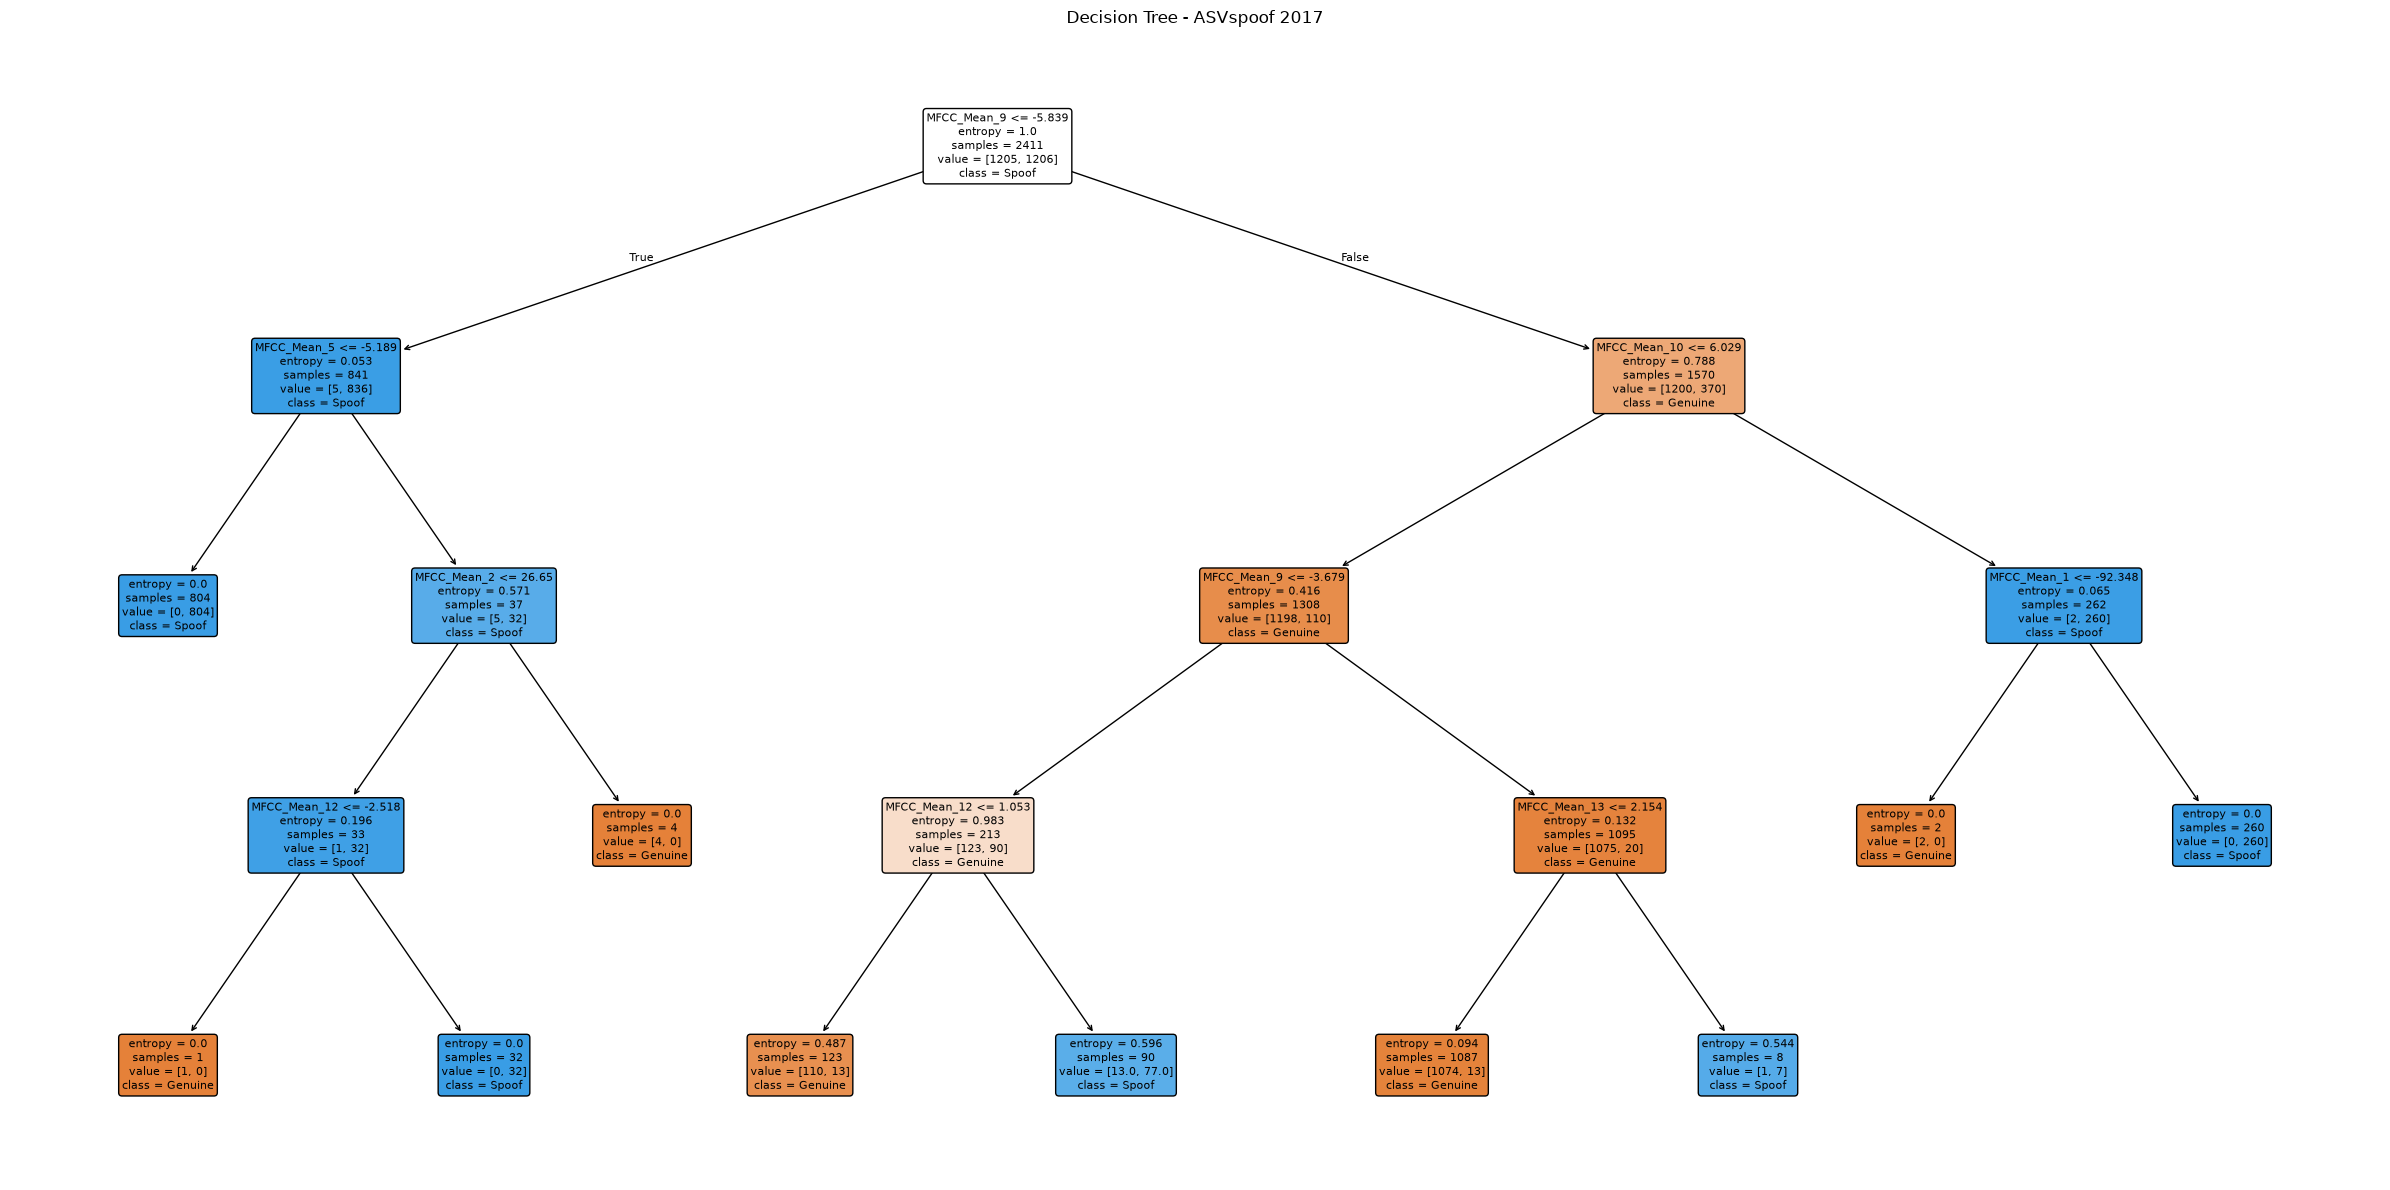

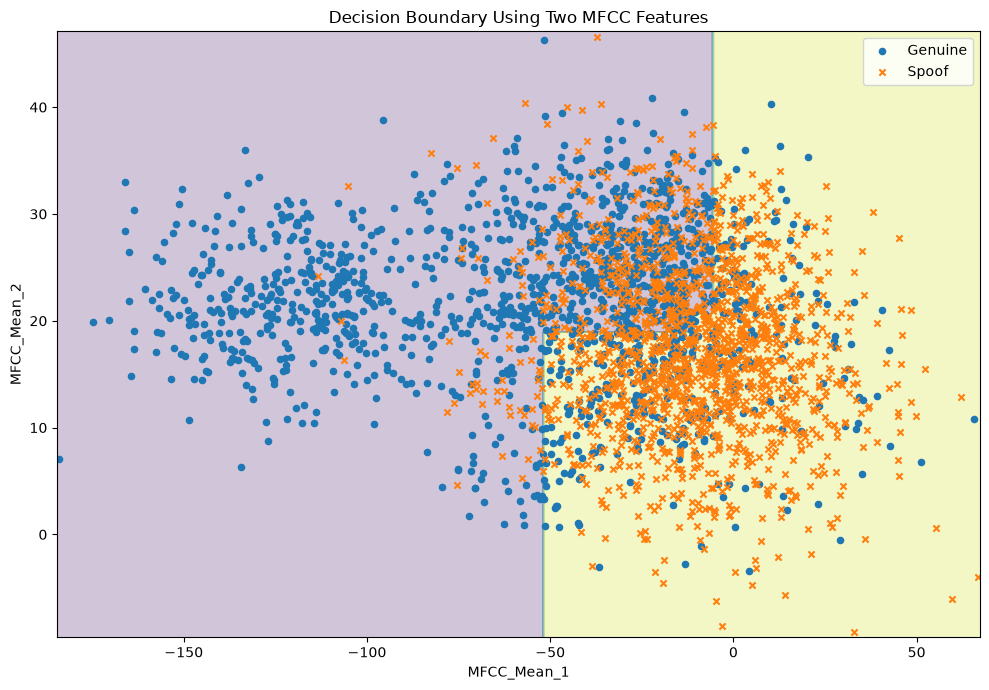


A7 - TWO FEATURE DECISION BOUNDARY
Features used: MFCC_Mean_1 and MFCC_Mean_2
Test Accuracy: 0.7313432835820896

A8 - Running GridSearchCV...

Best Hyperparameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.9805039389019183

Tuned Test Accuracy:
0.9651741293532339

Tuned Model Confusion Matrix:
[[291  11]
 [ 10 291]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

     Genuine       0.97      0.96      0.97       302
       Spoof       0.96      0.97      0.97       301

    accuracy                           0.97       603
   macro avg       0.97      0.97      0.97       603
weighted avg       0.97      0.97      0.97       603


              LAB 07 SUMMARY
Dataset: (3014, 26)
Entropy: 1.0
Gini Index: 0.5
Root Feature: MFCC_Mean_9
Root Information Gain: 0.4515061404508671
Custom Tree Accuracy: 0.9585406301824212
Two Feature Accuracy: 0.7313432835820896
Best

In [4]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.fft import rfft
from scipy.signal import get_window

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



# DATASET SETTINGS


DATA_DIR = r"C:\Users\DESLA\Desktop\ASV_2017\baseline_CM\baseline_CM\ASVspoof2017_V2_train"

PROTOCOL_DIR = r"C:\Users\DESLA\Desktop\ASV_2017\baseline_CM\baseline_CM\protocol_V2"

AUDIO_EXTENSIONS = {".wav", ".flac"}

RANDOM_STATE = 42
TEST_SIZE = 0.20



# DATA LOADING FUNCTIONS


def find_audio_files(data_dir):
    files = []

    for root, _, names in os.walk(data_dir):
        for name in names:
            if os.path.splitext(name)[1].lower() in AUDIO_EXTENSIONS:
                files.append(os.path.join(root, name))

    return sorted(files)


def find_protocol_files(protocol_dir):
    files = []

    for root, _, names in os.walk(protocol_dir):
        for name in names:
            files.append(os.path.join(root, name))

    return sorted(files)


def read_protocol(protocol_files):
    rows = []

    for path in protocol_files:

        try:

            with open(
                path,
                "r",
                encoding="utf-8",
                errors="ignore"
            ) as f:

                for line in f:

                    line = line.strip()

                    if not line:
                        continue

                    parts = line.split()

                    if len(parts) >= 2:
                        rows.append(parts)

        except Exception:
            pass

    return rows


def build_label_map(protocol_rows):

    label_map = {}

    for parts in protocol_rows:

        tokens = [x.lower() for x in parts]

        label = None

        if "genuine" in tokens:
            label = 0

        elif "spoof" in tokens:
            label = 1

        elif "bonafide" in tokens:
            label = 0

        elif "fake" in tokens:
            label = 1

        if label is None:
            continue

        candidates = [
            x for x in parts
            if x.lower().endswith((".wav", ".flac"))
        ]

        if not candidates:

            candidates = [
                x for x in parts
                if not x.replace(".", "", 1).isdigit()
            ]

        if candidates:

            key = os.path.splitext(
                os.path.basename(candidates[0])
            )[0].lower()

            label_map[key] = label

    return label_map



# MFCC FEATURE EXTRACTION


def hz_to_mel(hz):

    return 2595.0 * np.log10(
        1.0 + hz / 700.0
    )


def mel_to_hz(mel):

    return 700.0 * (
        10.0 ** (mel / 2595.0) - 1.0
    )


def mfcc_features(
    path,
    n_mfcc=13,
    n_fft=512,
    hop_length=256,
    n_mels=26
):

    sr, y = wavfile.read(path)

    y = np.asarray(
        y,
        dtype=np.float64
    )

    # Convert stereo to mono
    if y.ndim > 1:
        y = np.mean(y, axis=1)

    # Handle empty audio
    if y.size == 0:
        return np.zeros(
            n_mfcc * 2,
            dtype=np.float64
        )

    # Normalize audio
    y = y / (
        np.max(np.abs(y)) + 1e-12
    )

    frame_length = min(
        n_fft,
        max(32, y.size)
    )

    hop = min(
        hop_length,
        frame_length
    )

    if y.size < frame_length:

        y = np.pad(
            y,
            (0, frame_length - y.size)
        )

    n_frames = (
        1
        + max(
            0,
            (y.size - frame_length) // hop
        )
    )

    if n_frames < 1:
        n_frames = 1

    frames = np.zeros(
        (
            n_frames,
            frame_length
        ),
        dtype=np.float64
    )

    window = get_window(
        "hamming",
        frame_length,
        fftbins=True
    )

    for i in range(n_frames):

        start = i * hop

        segment = y[
            start:start + frame_length
        ]

        if segment.size < frame_length:

            segment = np.pad(
                segment,
                (
                    0,
                    frame_length - segment.size
                )
            )

        frames[i] = segment * window

    # Power spectrum
    spec = np.abs(
        rfft(
            frames,
            n=frame_length,
            axis=1
        )
    ) ** 2

    # Mel filter bank
    low_mel = hz_to_mel(0)

    high_mel = hz_to_mel(
        sr / 2.0
    )

    mel_points = np.linspace(
        low_mel,
        high_mel,
        n_mels + 2
    )

    hz_points = mel_to_hz(
        mel_points
    )

    bins = np.floor(
        (frame_length + 1)
        * hz_points
        / sr
    ).astype(int)

    bins = np.clip(
        bins,
        0,
        spec.shape[1] - 1
    )

    fb = np.zeros(
        (
            n_mels,
            spec.shape[1]
        )
    )

    for m in range(
        1,
        n_mels + 1
    ):

        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        if center <= left:

            center = min(
                left + 1,
                spec.shape[1] - 1
            )

        if right <= center:

            right = min(
                center + 1,
                spec.shape[1] - 1
            )

        if center > left:

            fb[
                m - 1,
                left:center
            ] = (
                np.arange(left, center)
                - left
            ) / (
                center - left
            )

        if right > center:

            fb[
                m - 1,
                center:right
            ] = (
                right
                - np.arange(center, right)
            ) / (
                right - center
            )

    mel_energy = np.maximum(
        spec @ fb.T,
        1e-12
    )

    log_mel = np.log(
        mel_energy
    )

    # DCT
    n = np.arange(
        n_mels
    )

    k = np.arange(
        n_mfcc
    )[:, None]

    dct = np.cos(
        np.pi
        / n_mels
        * (n + 0.5)
        * k
    )

    coeffs = (
        log_mel @ dct.T
    )

    # 13 means + 13 standard deviations
    features = np.concatenate(
        [
            coeffs.mean(axis=0),
            coeffs.std(axis=0)
        ]
    )

    return features


def audio_key(path):

    return os.path.splitext(
        os.path.basename(path)
    )[0].lower()


def infer_label_from_protocol(
    path,
    label_map
):

    key = audio_key(path)

    if key in label_map:
        return label_map[key]

    return None


# ============================================================
# CREATE DATASET X AND y
# ============================================================

print("Searching for audio files...")

audio_files = find_audio_files(
    DATA_DIR
)

print(
    "Number of audio files found:",
    len(audio_files)
)


print("\nReading protocol files...")

protocol_files = find_protocol_files(
    PROTOCOL_DIR
)

print(
    "Number of protocol files found:",
    len(protocol_files)
)


protocol_rows = read_protocol(
    protocol_files
)

print(
    "Protocol rows:",
    len(protocol_rows)
)


label_map = build_label_map(
    protocol_rows
)

print(
    "Labels available in protocol:",
    len(label_map)
)



# FEATURE EXTRACTION


X_list = []
y_list = []
used_files = []


print("\nExtracting MFCC features...")
print("This may take some time.")


for i, path in enumerate(
    audio_files
):

    label = infer_label_from_protocol(
        path,
        label_map
    )

    if label is None:
        continue

    try:

        features = mfcc_features(
            path
        )

        if np.all(
            np.isfinite(features)
        ):

            X_list.append(
                features
            )

            y_list.append(
                label
            )

            used_files.append(
                path
            )

    except Exception:
        continue


X = np.asarray(
    X_list,
    dtype=np.float64
)

y = np.asarray(
    y_list,
    dtype=np.int64
)


print("\n================ DATASET =================")

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "Class distribution:",
    np.unique(
        y,
        return_counts=True
    )
)

print(
    "=========================================="
)



# FEATURE NAMES


feature_names = []

for i in range(13):

    feature_names.append(
        f"MFCC_Mean_{i+1}"
    )

for i in range(13):

    feature_names.append(
        f"MFCC_Std_{i+1}"
    )



# A1 - EQUAL WIDTH BINNING


def equal_width_binning(
    values,
    n_bins=4
):

    values = np.asarray(
        values,
        dtype=float
    )

    if n_bins < 1:

        raise ValueError(
            "Number of bins must be at least 1."
        )

    minimum = np.min(
        values
    )

    maximum = np.max(
        values
    )

    if minimum == maximum:

        return np.zeros(
            len(values),
            dtype=int
        )

    edges = np.linspace(
        minimum,
        maximum,
        n_bins + 1
    )

    binned = np.digitize(
        values,
        edges[1:-1]
    )

    return binned



# A1 - ENTROPY


def calculate_entropy(
    labels
):

    labels = np.asarray(
        labels
    )

    if len(labels) == 0:
        return 0.0

    _, counts = np.unique(
        labels,
        return_counts=True
    )

    probabilities = (
        counts / len(labels)
    )

    entropy = 0.0

    for p in probabilities:

        if p > 0:

            entropy -= (
                p * np.log2(p)
            )

    return float(
        entropy
    )


entropy_value = calculate_entropy(
    y
)

print(
    "\nA1 - Entropy:",
    entropy_value
)



# A2 - GINI INDEX


def calculate_gini(
    labels
):

    labels = np.asarray(
        labels
    )

    if len(labels) == 0:
        return 0.0

    _, counts = np.unique(
        labels,
        return_counts=True
    )

    probabilities = (
        counts / len(labels)
    )

    gini = (
        1.0
        - np.sum(
            probabilities ** 2
        )
    )

    return float(
        gini
    )


gini_value = calculate_gini(
    y
)

print(
    "A2 - Gini Index:",
    gini_value
)



# A4 - BINNING FUNCTION


def bin_feature(
    values,
    method="equal_width",
    n_bins=4
):

    values = np.asarray(
        values,
        dtype=float
    )

    if n_bins < 1:

        raise ValueError(
            "Number of bins must be at least 1."
        )

    method = method.lower()

    # Equal-width binning
    if method == "equal_width":

        return equal_width_binning(
            values,
            n_bins
        )

    # Equal-frequency binning
    elif method in [
        "frequency",
        "equal_frequency"
    ]:

        ranks = pd.Series(
            values
        ).rank(
            method="first"
        )

        binned = pd.qcut(
            ranks,
            q=n_bins,
            labels=False,
            duplicates="drop"
        )

        return np.asarray(
            binned,
            dtype=int
        )

    else:

        raise ValueError(
            "method must be "
            "'equal_width' or "
            "'frequency'."
        )


# Test A4
sample_binning = bin_feature(
    X[:, 0],
    method="equal_width",
    n_bins=4
)

print(
    "\nA4 - Equal-width binning completed."
)

print(
    "Number of bins:",
    len(np.unique(sample_binning))
)



# A3 - INFORMATION GAIN


def information_gain(
    feature_values,
    labels,
    method="equal_width",
    n_bins=4
):

    labels = np.asarray(
        labels
    )

    binned_values = bin_feature(
        feature_values,
        method=method,
        n_bins=n_bins
    )

    parent_entropy = calculate_entropy(
        labels
    )

    weighted_child_entropy = 0.0

    for category in np.unique(
        binned_values
    ):

        mask = (
            binned_values == category
        )

        subset_labels = labels[
            mask
        ]

        weight = (
            len(subset_labels)
            / len(labels)
        )

        weighted_child_entropy += (
            weight
            * calculate_entropy(
                subset_labels
            )
        )

    return float(
        parent_entropy
        - weighted_child_entropy
    )


def find_root_feature(
    X,
    y,
    feature_names,
    method="equal_width",
    n_bins=4
):

    gains = []

    for feature_index in range(
        X.shape[1]
    ):

        gain = information_gain(
            X[:, feature_index],
            y,
            method=method,
            n_bins=n_bins
        )

        gains.append(
            gain
        )

    gains = np.asarray(
        gains
    )

    root_index = int(
        np.argmax(gains)
    )

    return (
        root_index,
        feature_names[root_index],
        gains
    )


root_index, root_name, information_gains = (
    find_root_feature(
        X,
        y,
        feature_names,
        method="equal_width",
        n_bins=4
    )
)


print(
    "\nA3 - ROOT FEATURE"
)

print(
    "Root feature:",
    root_name
)

print(
    "Feature index:",
    root_index
)

print(
    "Maximum Information Gain:",
    information_gains[root_index]
)


# Display all information gains
gain_table = pd.DataFrame({

    "Feature":
    feature_names,

    "Information_Gain":
    information_gains

}).sort_values(
    "Information_Gain",
    ascending=False
)


print(
    "\nInformation Gain of all features:"
)

print(
    gain_table.to_string(
        index=False
    )
)



# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )
)


print(
    "\nTrain samples:",
    len(X_train)
)

print(
    "Test samples:",
    len(X_test)
)



# A5 - CUSTOM DECISION TREE


class DecisionTreeNode:

    def __init__(
        self,
        feature_index=None,
        threshold=None,
        prediction=None,
        left=None,
        right=None,
        depth=0
    ):

        self.feature_index = (
            feature_index
        )

        self.threshold = (
            threshold
        )

        self.prediction = (
            prediction
        )

        self.left = left

        self.right = right

        self.depth = depth


class CustomDecisionTree:

    def __init__(
        self,
        max_depth=4,
        min_samples_split=2,
        min_gain=1e-10
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_gain = min_gain

        self.root = None


    def _majority_class(
        self,
        y
    ):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[
            np.argmax(counts)
        ]


    def _best_split(
        self,
        X,
        y
    ):

        parent_entropy = (
            calculate_entropy(y)
        )

        best_gain = -1.0

        best_feature = None

        best_threshold = None

        n_samples, n_features = (
            X.shape
        )


        for feature_index in range(
            n_features
        ):

            values = np.unique(
                X[:, feature_index]
            )

            if len(values) < 2:
                continue


            thresholds = (
                values[:-1]
                + values[1:]
            ) / 2.0


            for threshold in thresholds:

                left_mask = (
                    X[:, feature_index]
                    <= threshold
                )

                right_mask = ~left_mask


                if (
                    np.sum(left_mask) == 0
                    or np.sum(right_mask) == 0
                ):

                    continue


                left_y = y[
                    left_mask
                ]

                right_y = y[
                    right_mask
                ]


                weighted_entropy = (

                    (
                        len(left_y)
                        / n_samples
                    )
                    * calculate_entropy(
                        left_y
                    )

                    +

                    (
                        len(right_y)
                        / n_samples
                    )
                    * calculate_entropy(
                        right_y
                    )
                )


                gain = (
                    parent_entropy
                    - weighted_entropy
                )


                if gain > best_gain:

                    best_gain = gain

                    best_feature = (
                        feature_index
                    )

                    best_threshold = (
                        threshold
                    )


        return (
            best_feature,
            best_threshold,
            best_gain
        )


    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        majority = (
            self._majority_class(y)
        )


        if (
            len(np.unique(y)) == 1

            or

            len(y)
            < self.min_samples_split

            or

            (
                self.max_depth
                is not None

                and

                depth
                >= self.max_depth
            )
        ):

            return DecisionTreeNode(
                prediction=majority,
                depth=depth
            )


        (
            feature_index,
            threshold,
            gain
        ) = self._best_split(
            X,
            y
        )


        if (
            feature_index is None
            or
            gain <= self.min_gain
        ):

            return DecisionTreeNode(
                prediction=majority,
                depth=depth
            )


        left_mask = (
            X[:, feature_index]
            <= threshold
        )

        right_mask = ~left_mask


        left_child = (
            self._build_tree(
                X[left_mask],
                y[left_mask],
                depth + 1
            )
        )


        right_child = (
            self._build_tree(
                X[right_mask],
                y[right_mask],
                depth + 1
            )
        )


        return DecisionTreeNode(

            feature_index=
            feature_index,

            threshold=
            threshold,

            left=
            left_child,

            right=
            right_child,

            depth=
            depth
        )


    def fit(
        self,
        X,
        y
    ):

        X = np.asarray(
            X,
            dtype=float
        )

        y = np.asarray(
            y
        )

        self.root = (
            self._build_tree(
                X,
                y,
                depth=0
            )
        )

        return self


    def _predict_one(
        self,
        row,
        node
    ):

        if node.prediction is not None:

            return node.prediction


        if (
            row[node.feature_index]
            <= node.threshold
        ):

            return self._predict_one(
                row,
                node.left
            )


        return self._predict_one(
            row,
            node.right
        )


    def predict(
        self,
        X
    ):

        X = np.asarray(
            X,
            dtype=float
        )

        return np.asarray([

            self._predict_one(
                row,
                self.root
            )

            for row in X

        ])


# Train custom tree
custom_tree = CustomDecisionTree(
    max_depth=4,
    min_samples_split=2
)

custom_tree.fit(
    X_train,
    y_train
)


custom_predictions = (
    custom_tree.predict(
        X_test
    )
)


custom_accuracy = (
    accuracy_score(
        y_test,
        custom_predictions
    )
)


print(
    "\nA5 - CUSTOM DECISION TREE"
)

print(
    "Accuracy:",
    custom_accuracy
)

print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        custom_predictions
    )
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        custom_predictions,
        target_names=[
            "Genuine",
            "Spoof"
        ],
        zero_division=0
    )
)



# A6 - DECISION TREE VISUALIZATION


tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=RANDOM_STATE
)

tree_model.fit(
    X_train,
    y_train
)


plt.figure(
    figsize=(24, 12)
)

plot_tree(

    tree_model,

    feature_names=
    feature_names,

    class_names=[
        "Genuine",
        "Spoof"
    ],

    filled=True,

    rounded=True,

    fontsize=8

)

plt.title(
    "Decision Tree - ASVspoof 2017"
)

plt.tight_layout()

plt.show()



# A7 - TWO FEATURE DECISION BOUNDARY


# Use first two MFCC mean features
feature_1 = 0
feature_2 = 1


X_two = X[
    :,
    [feature_1, feature_2]
]


X2_train, X2_test, y2_train, y2_test = (
    train_test_split(
        X_two,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )
)


two_feature_tree = (
    DecisionTreeClassifier(
        criterion="entropy",
        max_depth=4,
        random_state=RANDOM_STATE
    )
)


two_feature_tree.fit(
    X2_train,
    y2_train
)


x_min = (
    X_two[:, 0].min()
    - 0.5
)

x_max = (
    X_two[:, 0].max()
    + 0.5
)

y_min = (
    X_two[:, 1].min()
    - 0.5
)

y_max = (
    X_two[:, 1].max()
    + 0.5
)


xx, yy = np.meshgrid(

    np.linspace(
        x_min,
        x_max,
        300
    ),

    np.linspace(
        y_min,
        y_max,
        300
    )
)


grid_points = np.c_[

    xx.ravel(),

    yy.ravel()

]


grid_predictions = (
    two_feature_tree.predict(
        grid_points
    )
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.contourf(

    xx,

    yy,

    grid_predictions,

    alpha=0.25

)


plt.scatter(

    X_two[
        y == 0,
        0
    ],

    X_two[
        y == 0,
        1
    ],

    label="Genuine",

    s=20

)


plt.scatter(

    X_two[
        y == 1,
        0
    ],

    X_two[
        y == 1,
        1
    ],

    label="Spoof",

    s=20,

    marker="x"

)


plt.xlabel(
    feature_names[
        feature_1
    ]
)

plt.ylabel(
    feature_names[
        feature_2
    ]
)

plt.title(
    "Decision Boundary Using Two MFCC Features"
)

plt.legend()

plt.tight_layout()

plt.show()


two_feature_predictions = (
    two_feature_tree.predict(
        X2_test
    )
)


two_feature_accuracy = (
    accuracy_score(
        y2_test,
        two_feature_predictions
    )
)


print(
    "\nA7 - TWO FEATURE DECISION BOUNDARY"
)

print(
    "Features used:",
    feature_names[feature_1],
    "and",
    feature_names[feature_2]
)

print(
    "Test Accuracy:",
    two_feature_accuracy
)



# A8 - GRIDSEARCHCV HYPERPARAMETER TUNING


parameter_grid = {

    "criterion": [
        "gini",
        "entropy"
    ],

    "max_depth": [
        2,
        3,
        4,
        5,
        6,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]

}


grid_search = GridSearchCV(

    estimator=
    DecisionTreeClassifier(
        random_state=
        RANDOM_STATE
    ),

    param_grid=
    parameter_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)


print(
    "\nA8 - Running GridSearchCV..."
)

grid_search.fit(
    X_train,
    y_train
)


best_model = (
    grid_search.best_estimator_
)


best_predictions = (
    best_model.predict(
        X_test
    )
)


best_accuracy = (
    accuracy_score(
        y_test,
        best_predictions
    )
)


print(
    "\nBest Hyperparameters:"
)

print(
    grid_search.best_params_
)


print(
    "\nBest Cross-Validation Accuracy:"
)

print(
    grid_search.best_score_
)


print(
    "\nTuned Test Accuracy:"
)

print(
    best_accuracy
)


print(
    "\nTuned Model Confusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        best_predictions
    )
)


print(
    "\nTuned Model Classification Report:"
)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Genuine",
            "Spoof"
        ],
        zero_division=0
    )
)


# FINAL LAB 07 SUMMARY


print(
    "\n================================================"
)

print(
    "              LAB 07 SUMMARY"
)

print(
    "================================================"
)

print(
    "Dataset:",
    X.shape
)

print(
    "Entropy:",
    entropy_value
)

print(
    "Gini Index:",
    gini_value
)

print(
    "Root Feature:",
    root_name
)

print(
    "Root Information Gain:",
    information_gains[
        root_index
    ]
)

print(
    "Custom Tree Accuracy:",
    custom_accuracy
)

print(
    "Two Feature Accuracy:",
    two_feature_accuracy
)

print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best CV Accuracy:",
    grid_search.best_score_
)

print(
    "Tuned Test Accuracy:",
    best_accuracy
)

print(
    "================================================"
)